# Introduction

This comprehensive notebook demonstrates the **multimodal capabilities** of **Google's Gemini API** using the latest models and features.

## What You'll Learn

### API Fundamentals
- Single vs batch processing
- Streaming responses
- Configuration options
- Error handling

### Text Capabilities (10 examples)
- Sentiment analysis, classification, NER
- Summarization, Q&A, translation
- Text completion and rewriting
- Entity and keyword extraction

### Vision Capabilities (8 examples)
- Object counting and visual Q&A
- Chart and document analysis
- Image captioning and comparison
- Visual reasoning and diagrams

### Video Capabilities (3 examples)
- Video understanding and analysis
- Frame-by-frame analysis
- Action recognition

### Audio Capabilities (2 examples)
- Speech transcription
- Audio content analysis

### PDF Capabilities (2 examples)
- Document analysis
- Multi-page extraction

### Advanced Features (8 examples)
- Structured JSON output
- Function calling
- Code execution
- Search grounding
- Long context (1M tokens)
- Code generation
- Mathematical and scientific reasoning
- Creative writing

## Model Used

**Model:** `gemini-2.0-flash-thinking-exp-1219`
- **Input modalities:** Text, Image, Video, Audio, PDF
- **Output:** Text
- **Context:** 1M+ tokens input, 65K+ tokens output
- **Special features:** Code execution, search grounding, thinking mode

# Setup and Configuration

In [5]:
# Install required packages
# !pip install google-genai pillow requests matplotlib pandas numpy

In [18]:
import os
import json
import time
from pathlib import Path
from typing import List, Dict, Any
from google import genai
from PIL import Image, ImageDraw, ImageFont
import requests
from io import BytesIO
import base64
import matplotlib.pyplot as plt
import numpy as np

# Check for API key
if 'GEMINI_API_KEY' not in os.environ:
    raise ValueError(
        "GEMINI_API_KEY not found in environment.\n"
        "Set it with: export GEMINI_API_KEY='your-key'\n"
        "Get your key at: https://aistudio.google.com/apikey"
    )

# Initialize client (new SDK)
client = genai.Client(api_key=os.environ['GEMINI_API_KEY'])

print(" Gemini client initialized successfully")
print("Using google-genai SDK (new version)")

# Note: We'll use gemini-2.0-flash-thinking-exp-1219 as the default model
MODEL = "gemini-2.0-flash-thinking-exp-1219"
print(f"Default model: {MODEL}")

✅ Gemini client initialized successfully
Using google-genai SDK (new version)
Default model: gemini-2.0-flash-thinking-exp-1219


## Helper Functions

In [19]:
def print_section(title: str):
    """Print formatted section header."""
    print("\n" + "="*80)
print(title)
print("="*80)

def print_result(label: str, content: str, indent: int = 0):
    """Print formatted result."""
    prefix = "  " * indent
    print(f"{prefix}{label}: {content}")

def load_image_from_url(url: str) -> Image.Image:
    """Load an image from a URL."""
    response = requests.get(url)
    return Image.open(BytesIO(response.content))

def create_sample_image(text: str, size=(800, 600)) -> Image.Image:
    """Create a simple image with text for testing."""
    img = Image.new('RGB', size, color='white')
    draw = ImageDraw.Draw(img)
    draw.text((50, size[1]//2), text, fill='black')
    return img

print("Helper functions loaded")

Helper functions loaded


# Part 1: API Usage Patterns

## Single Request vs Batch Processing

In [ ]:
print("Single Request")
print("="*80)

# Single request - simplest way
response = client.models.generate_content(
    model="gemini-3-pro-preview",
    contents="What is the capital of France?")
print_result("Question", "What is the capital of France?")
print_result("Answer", response.text)


TASK 0A: Single Request
Question: What is the capital of France?
Answer: The capital of France is **Paris**.


In [21]:
print("\n" + "="*80)
print("Batch Processing")
print("="*80)

# Process multiple prompts efficiently
prompts = [
    "Translate 'Hello' to Spanish",
    "Translate 'Goodbye' to French",
    "Translate 'Thank you' to German",
    "Translate 'Welcome' to Italian"
]

# Method 1: Sequential (simple but slower)
print("Sequential processing:")
start = time.time()
results_seq = []
for prompt in prompts:
    response = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=prompt)
    results_seq.append(response.text.strip())
time_seq = time.time() - start

for i, (prompt, result) in enumerate(zip(prompts, results_seq), 1):
    print(f"  {i}. {prompt} → {result}")
print(f"Time: {time_seq:.2f}s")


TASK 0B: Batch Processing
Sequential processing:
  1. Translate 'Hello' to Spanish → The most common way to say "Hello" in Spanish is:

**Hola**
  2. Translate 'Goodbye' to French → The most common translation for "Goodbye" in French is:

**Au revoir**

You might also hear:

*   **Adieu** (more definitive, often implies "farewell forever," though sometimes used in literature for a simple "goodbye")
*   **Salut** (informal, used for both "hi" and "bye")
*   **À bientôt** (See you soon)
*   **À tout à l'heure** (See you later today)
*   **À demain** (See you tomorrow)
*   **Bonne journée** (Have a good day)
*   **Bonne soirée** (Have a good evening)
*   **Bonne nuit** (Good night)
  3. Translate 'Thank you' to German → The most common ways to say "Thank you" in German are:

1.  **Danke** (Most common, general, can be informal but also widely accepted in formal settings)
2.  **Danke schön** (Slightly more polite or appreciative than just "Danke")

Other options, expressing stronger grati

## Configuration and Safety Settings

In [22]:
print_task("0C", "Streaming Responses")

# Stream responses for long-running tasks
prompt = """Write a detailed explanation of how neural networks work,
covering architecture, training process, and applications."""

print("Streaming response (token by token):\n")

response = client.models.generate_content_stream(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=prompt
)

for chunk in response:
    if chunk.text:
        print(chunk.text, end='', flush=True)

print("\n\nStreaming complete!")


TASK 0C: Streaming Responses
Streaming response (token by token):

Neural networks are a subset of machine learning, inspired by the structure and function of the human brain. They are powerful tools capable of learning complex patterns and relationships within data, enabling them to perform tasks like image recognition, natural language processing, and prediction with remarkable accuracy.

Let's break down how they work in detail:

---

## 1. The Core Building Block: The Neuron (or Perceptron)

At its heart, a neural network is a collection of interconnected "neurons." A single artificial neuron, also called a **perceptron**, mimics the basic function of a biological neuron:

1.  **Inputs (x):** It receives multiple input signals, which are typically numerical values.
2.  **Weights (w):** Each input is multiplied by a specific "weight." Weights represent the strength or importance of that input connection. A higher weight means that input has a greater influence on the neuron's outpu

# Part 2: Text-Only Tasks (10 tasks)

In [24]:
print("\n" + "="*80)
print("Zero-Shot Sentiment Analysis")
print("="*80)

texts = [
    "This product is absolutely amazing! Best purchase I've made all year.",
    "Terrible experience. Waste of money and time.",
    "It's okay. Nothing special but does the job.",
    "I'm disappointed with the quality. Expected much better.",
    "Exceeded all my expectations! Highly recommend!"
]

prompt_template = """Classify the sentiment: Positive, Negative, or Neutral.
Reply with ONLY the sentiment label.

Text: {text}
Sentiment:"""

for i, text in enumerate(texts, 1):
    response = client.models.generate_content(
        model="gemini-2.0-flash-thinking-exp-1219",
        contents=prompt_template.format(text=text)
    )
    sentiment = response.text.strip()
print(f"{i}. '{text[:50]}...'")
print(f"   → {sentiment}\n")


TASK 1: Zero-Shot Sentiment Analysis
1. 'This product is absolutely amazing! Best purchase ...'
   → Positive

2. 'Terrible experience. Waste of money and time....'
   → Negative

3. 'It's okay. Nothing special but does the job....'
   → Neutral

4. 'I'm disappointed with the quality. Expected much b...'
   → Negative

5. 'Exceeded all my expectations! Highly recommend!...'
   → Positive



## Few-Shot Text Classification

In [25]:
print("\n" + "="*80)
print("Few-Shot Text Classification")
print("="*80)

# Intent classification with examples
prompt = """Classify customer service queries into categories.

Examples:
"How do I reset my password?" → Technical Support
"I was charged twice" → Billing
"What are your hours?" → General Inquiry
"This is broken" → Complaint
"I want to cancel" → Account Management

Query: "{query}"
Category:"""

test_queries = [
    "My app keeps crashing when I upload photos",
    "Why was I charged for premium when I'm on free plan?",
    "Do you ship to Canada?",
    "The product arrived damaged",
    "How do I delete my account?"
]

for query in test_queries:
    response = client.models.generate_content(
        model="gemini-2.0-flash-thinking-exp-1219",
        contents=prompt.format(query=query)
    )
print(f"Query: {query}")
print(f"Category: {response.text.strip()}\n")


TASK 2: Few-Shot Text Classification
Query: My app keeps crashing when I upload photos
Category: Technical Support

Query: Why was I charged for premium when I'm on free plan?
Category: Category: Billing

Query: Do you ship to Canada?
Category: Category: General Inquiry

Query: The product arrived damaged
Category: Complaint

Query: How do I delete my account?
Category: Account Management



## Named Entity Recognition

In [26]:
print("\n" + "="*80)
print("Named Entity Recognition (NER)")
print("="*80)

text = """Apple Inc. CEO Tim Cook announced a $500 million investment in renewable 
energy projects across California next month. The announcement was made at the 
company's headquarters in Cupertino on December 15, 2024."""

prompt = f"""Extract all named entities and categorize them:
PERSON, ORGANIZATION, LOCATION, MONEY, DATE

Text: {text}

Format as JSON with entity type as key."""

response = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=prompt)
print(f"Text: {text}\n")
print("Entities:")
print(response.text)


TASK 3: Named Entity Recognition (NER)
Text: Apple Inc. CEO Tim Cook announced a $500 million investment in renewable 
energy projects across California next month. The announcement was made at the 
company's headquarters in Cupertino on December 15, 2024.

Entities:
```json
{
  "PERSON": [
    "Tim Cook"
  ],
  "ORGANIZATION": [
    "Apple Inc."
  ],
  "LOCATION": [
    "California",
    "Cupertino"
  ],
  "MONEY": [
    "$500 million"
  ],
  "DATE": [
    "December 15, 2024"
  ]
}
```


## Text Summarization

In [27]:
print("\n" + "="*80)
print("Text Summarization")
print("="*80)

article = """Artificial intelligence continues to transform industries worldwide. Recent
advances in large language models have enabled more natural conversations between humans
and machines. These models can understand context, generate coherent text, and even
perform complex reasoning tasks. However, challenges remain in ensuring factual accuracy,
reducing computational costs, and addressing ethical concerns around bias and privacy.
Researchers are actively working on making AI more efficient, transparent, and aligned
with human values. The field is evolving rapidly, with new breakthroughs announced weekly.
From healthcare to education, AI is reshaping how we work and live."""

prompts = [
    "Summarize in 1 sentence:",
    "Summarize in 3 bullet points:",
    "Create a tweet-length summary (280 chars):"
]

print(f"Original ({len(article)} chars):\n{article}\n")

for prompt_type in prompts:
    response = client.models.generate_content(
        model="gemini-2.0-flash-thinking-exp-1219",
        contents=f"{prompt_type}\n\n{article}"
    )
print(f"{prompt_type}")
print(f"  {response.text.strip()}\n")


TASK 4: Text Summarization
Original (671 chars):
Artificial intelligence continues to transform industries worldwide. Recent
advances in large language models have enabled more natural conversations between humans
and machines. These models can understand context, generate coherent text, and even
perform complex reasoning tasks. However, challenges remain in ensuring factual accuracy,
reducing computational costs, and addressing ethical concerns around bias and privacy.
Researchers are actively working on making AI more efficient, transparent, and aligned
with human values. The field is evolving rapidly, with new breakthroughs announced weekly.
From healthcare to education, AI is reshaping how we work and live.

Summarize in 1 sentence:
  Driven by advancements in large language models, artificial intelligence is rapidly transforming industries and human-machine interaction worldwide, despite ongoing challenges in accuracy, cost, and ethics.

Summarize in 3 bullet points:
  Here's a t

## Question Answering with Context

In [28]:
print("\n" + "="*80)
print("Question Answering")
print("="*80)

context = """The Eiffel Tower is a wrought-iron lattice tower located on the Champ de Mars
in Paris, France. It was constructed from 1887 to 1889 as the centerpiece of the 1889
World's Fair. The tower is 330 meters (1,083 feet) tall, about the same height as an
81-story building. It was the tallest man-made structure in the world until the Chrysler
Building was completed in New York in 1930."""

questions = [
    "When was the Eiffel Tower built?",
    "How tall is the Eiffel Tower?",
    "Where is it located?",
    "What material is it made of?",
    "When did it stop being the tallest structure?"
]

print(f"Context: {context}\n")

for q in questions:
    prompt = f"Context: {context}\n\nQuestion: {q}\nAnswer (concise):"
    response = client.models.generate_content(
        model="gemini-2.0-flash-thinking-exp-1219",
        contents=prompt
    )
print(f"Q: {q}")
print(f"A: {response.text.strip()}\n")


TASK 5: Question Answering
Context: The Eiffel Tower is a wrought-iron lattice tower located on the Champ de Mars
in Paris, France. It was constructed from 1887 to 1889 as the centerpiece of the 1889
World's Fair. The tower is 330 meters (1,083 feet) tall, about the same height as an
81-story building. It was the tallest man-made structure in the world until the Chrysler
Building was completed in New York in 1930.

Q: When was the Eiffel Tower built?
A: 1887 to 1889

Q: How tall is the Eiffel Tower?
A: 330 meters (1,083 feet)

Q: Where is it located?
A: On the Champ de Mars in Paris, France.

Q: What material is it made of?
A: Wrought-iron

Q: When did it stop being the tallest structure?
A: 1930



## Translation

In [30]:
print("\n" + "="*80)
print("Multi-Language Translation")
print("="*80)

text = "Artificial intelligence is changing the world."
languages = ["Spanish", "French", "German", "Japanese", "Hindi", "Arabic"]

print(f"Original (English): {text}\n")

for lang in languages:
    prompt = f"Translate to {lang}: {text}"
    response = client.models.generate_content(
        model="gemini-2.0-flash-thinking-exp-1219",
        contents=prompt
    )
print(f"{lang}: {response.text.strip()}")


TASK 6: Multi-Language Translation
Original (English): Artificial intelligence is changing the world.

Spanish: **La inteligencia artificial está cambiando el mundo.**
French: **L'intelligence artificielle change le monde.**
German: **Künstliche Intelligenz verändert die Welt.**
Japanese: 人工知能は世界を変えています。
(Jinkō chinō wa sekai o kaete imasu.)

**More nuanced options:**

*   **Emphasizing a gradual, ongoing process:**
    人工知能は世界を変えつつあります。
    (Jinkō chinō wa sekai o kaetsutsu arimasu.)
    *This implies the change is currently happening and will continue.*

*   **Emphasizing a transformative or revolutionary change:**
    人工知能は世界を変革しています。
    (Jinkō chinō wa sekai o henkaku shite imasu.)
    *「変革 (henkaku)」 means transformation or reform, often implying a more profound change.*
Hindi: Here are a couple of ways to translate "Artificial intelligence is changing the world" into Hindi, both are commonly used and accurate:

1.  **कृत्रिम बुद्धिमत्ता दुनिया बदल रही है।**
    *   (Kritrim Bud

## Text Completion

In [31]:
print("\n" + "="*80)
print("Text Completion")
print("="*80)

prompts = [
    "The secret to happiness is",
    "In the year 2050, technology will",
    "The most important skill for the future is"
]

for prompt in prompts:
    response = client.models.generate_content(
        model="gemini-2.0-flash-thinking-exp-1219",
        contents=f"Complete this sentence in 1-2 sentences: {prompt}"
    )
print(f"Prompt: '{prompt}'")
print(f"Completion: {response.text.strip()}\n")


TASK 7: Text Completion
Prompt: 'The secret to happiness is'
Completion: The secret to happiness is **not a destination to be reached, but a journey of perspective and gratitude**. It's found in embracing the present moment, fostering meaningful connections, and cultivating contentment with what you have rather than constantly chasing what you lack.

Prompt: 'In the year 2050, technology will'
Completion: In the year 2050, technology will be largely invisible yet profoundly influential, with advanced AI seamlessly anticipating needs and automating complex tasks across all sectors. This pervasive integration will revolutionize everything from personalized healthcare and autonomous transportation to our interaction with smart environments, making daily life remarkably efficient and interconnected.

Prompt: 'The most important skill for the future is'
Completion: The most important skill for the future is **adaptability**. As technology accelerates and industries transform, the ability t

## Entity Extraction

In [32]:
print("\n" + "="*80)
print("Structured Entity Extraction")
print("="*80)

resume = """JOHN DOE
john.doe@email.com | (555) 123-4567 | linkedin.com/in/johndoe

EXPERIENCE
Senior Software Engineer, TechCorp (2020-Present)
- Led team of 5 engineers in developing cloud infrastructure
- Expertise: Python, AWS, Docker, Kubernetes

EDUCATION
M.S. Computer Science, Stanford University (2018)
B.S. Computer Science, MIT (2016)"""

prompt = f"""Extract key information as JSON:
{{
  "name": "",
  "email": "",
  "phone": "",
  "current_role": "",
  "company": "",
  "skills": [],
  "education": []
}}

Resume:
{resume}

Return only valid JSON:"""

response = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=prompt)
print("Extracted data:")
print(response.text)


TASK 8: Structured Entity Extraction
Extracted data:
```json
{
  "name": "JOHN DOE",
  "email": "john.doe@email.com",
  "phone": "(555) 123-4567",
  "current_role": "Senior Software Engineer",
  "company": "TechCorp",
  "skills": [
    "Python",
    "AWS",
    "Docker",
    "Kubernetes"
  ],
  "education": [
    "M.S. Computer Science, Stanford University (2018)",
    "B.S. Computer Science, MIT (2016)"
  ]
}
```


## Keyword Extraction

In [33]:
print("\n" + "="*80)
print("Keyword Extraction")
print("="*80)

text = """Machine learning and deep learning are subsets of artificial intelligence 
that focus on training algorithms to recognize patterns in data. Neural networks, 
inspired by biological neurons, form the basis of deep learning systems. These 
technologies power applications like computer vision, natural language processing, 
and autonomous vehicles."""

prompt = f"""Extract the 5 most important keywords from this text.
Return as a comma-separated list.

Text: {text}

Keywords:"""

response = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=prompt)
print(f"Text: {text}\n")
print(f"Keywords: {response.text.strip()}")


TASK 9: Keyword Extraction
Text: Machine learning and deep learning are subsets of artificial intelligence 
that focus on training algorithms to recognize patterns in data. Neural networks, 
inspired by biological neurons, form the basis of deep learning systems. These 
technologies power applications like computer vision, natural language processing, 
and autonomous vehicles.

Keywords: Artificial Intelligence, Machine Learning, Deep Learning, Neural Networks, Computer Vision


## Text Rewriting

In [34]:
print("\n" + "="*80)
print("Text Rewriting for Different Audiences")
print("="*80)

original = """The algorithm leverages advanced neural architectures to optimize
multi-dimensional parameter spaces through stochastic gradient descent."""

audiences = [
    "Explain to a 10-year-old",
    "Rewrite for a business executive",
    "Simplify for general audience",
    "Make it poetic"
]

print(f"Original: {original}\n")

for audience in audiences:
    response = client.models.generate_content(
        model="gemini-2.0-flash-thinking-exp-1219",
        contents=f"{audience}:\n\n{original}"
    )
print(f"{audience}:")
print(f"  {response.text.strip()}\n")


TASK 10: Text Rewriting for Different Audiences
Original: The algorithm leverages advanced neural architectures to optimize
multi-dimensional parameter spaces through stochastic gradient descent.

Explain to a 10-year-old:
  Okay, imagine you have a very smart robot that needs to learn how to do something perfectly – like playing a video game really, really well, or figuring out the best way to sort a giant pile of toys.

Let's break down that big sentence:

1.  **"The algorithm"**: This is just the robot's special plan or recipe for how it's going to learn and do things. It's a set of instructions.

2.  **"leverages advanced neural architectures"**: This means the robot uses a special "brain" inside it. This computer brain isn't like a human brain, but it's *inspired* by how our brains work, with lots of tiny connections. It's really good at learning from examples, kind of like how you learn by practicing.

3.  **"to optimize"**: This simply means the robot wants to find the *best po

# Part 3: Vision Tasks (8 tasks)

## Object Counting


TASK 11: Object Counting in Images


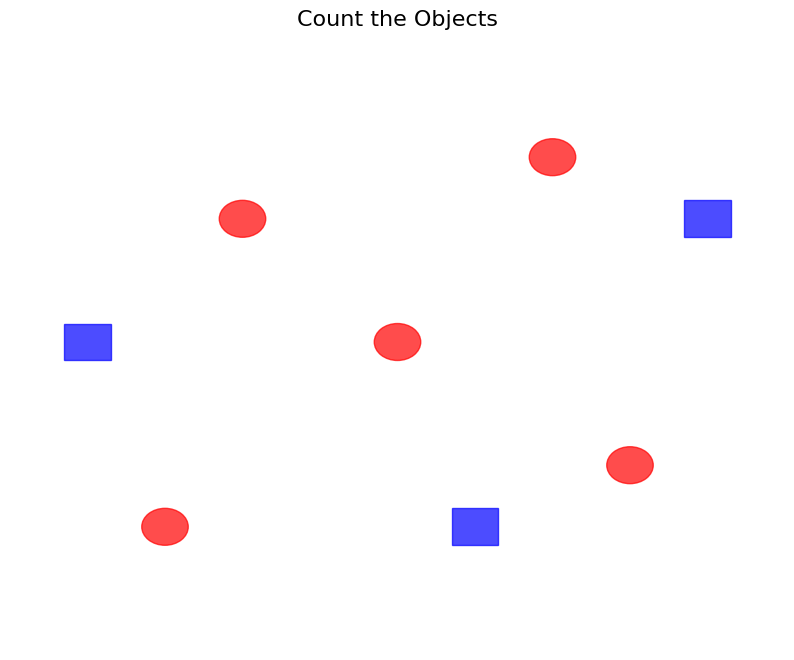

In [36]:
print("\n" + "="*80)
print("Object Counting in Images")
print("="*80)

# Create a test image with multiple objects
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Draw different shapes
circles = [(2, 2), (5, 5), (8, 3), (3, 7), (7, 8)]
squares_x = [1, 6, 9]
squares_y = [5, 2, 7]

for x, y in circles:
    circle = plt.Circle((x, y), 0.3, color='red', alpha=0.7)
    ax.add_patch(circle)

from matplotlib.patches import Rectangle
for x, y in zip(squares_x, squares_y):
    square = Rectangle((x-0.3, y-0.3), 0.6, 0.6, color='blue', alpha=0.7)
    ax.add_patch(square)

plt.title('Count the Objects', fontsize=16)
plt.savefig('/tmp/objects.png', dpi=150, bbox_inches='tight')


In [37]:
plt.close()

image = Image.open('/tmp/objects.png')

prompt = """Count the objects in this image:
1. How many red circles?
2. How many blue squares?
3. Total number of objects?"""

response = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=[prompt, image])
print(response.text)

Here are the counts for the objects in the image:

1.  **How many red circles?** 5
2.  **How many blue squares?** 2
3.  **Total number of objects?** 7


## Visual Question Answering (VQA)


TASK 12: Visual Question Answering
Q: What is the dominant color in this image?
A: The dominant color in this image is a **desaturated blue** or **blue-grey**.

This hue is prominent in:
*   The large expanse of sky, particularly on the left side.
*   The vast sea of clouds/fog filling the valley.
*   The distant mountains, which appear bluer due to atmospheric perspective.

While there are touches of orange/pink in the sunset sky and white on the snow-capped peaks, the cool, muted blue tones cover the largest area of the image.

Q: Describe the scenery
A: This breathtaking scenery captures a majestic mountain landscape at either sunrise or sunset, viewed from a high vantage point above a vast sea of clouds.

In the immediate foreground, dark, rugged, and somewhat sparse terrain provides a stark contrast to the softness beyond, suggesting a rocky ridge or peak where the viewer is positioned.

Below, the midground is dominated by an expansive "cloud inversion," where a thick, undulatin

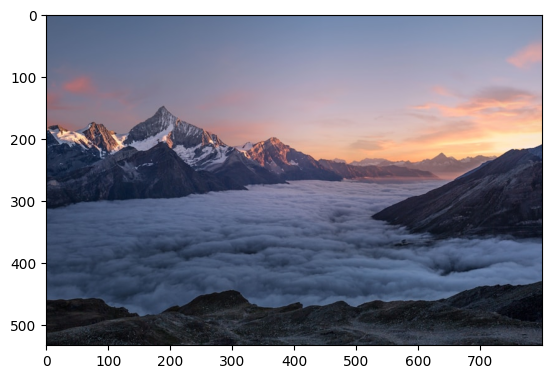

In [38]:
print("\n" + "="*80)
print("Visual Question Answering")
print("="*80)

# Use sample images from URLs
try:
    image_url = "https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=800"
    image = load_image_from_url(image_url)

    # Show image
    plt.imshow(image)
    
    questions = [
        "What is the dominant color in this image?",
        "Describe the scenery",
        "What time of day does it appear to be?",
        "What mood does this image convey?"
    ]

    for q in questions:
        response = client.models.generate_content(
            model="gemini-2.0-flash-thinking-exp-1219",
            contents=[q, image]
        )
print(f"Q: {q}")
print(f"A: {response.text.strip()}\n")

except Exception as e:
    print(f"Note: Image loading requires internet. Error: {str(e)[:100]}")

## Chart and Graph Analysis


TASK 13: Chart Analysis


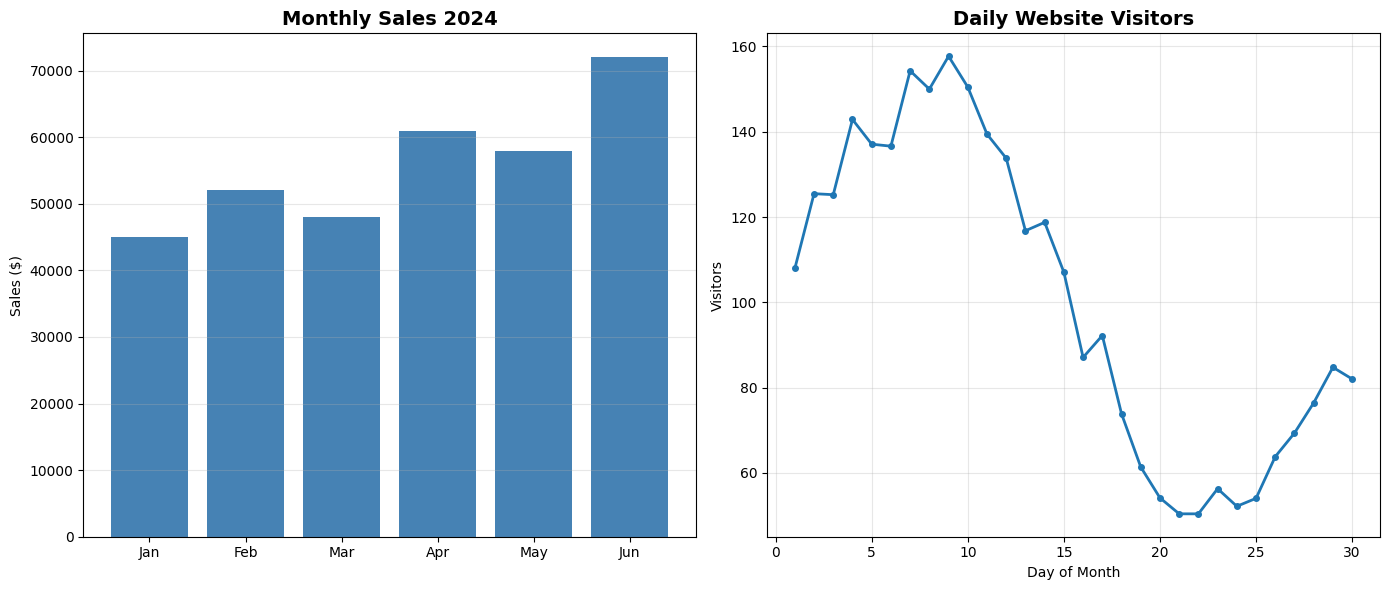

In [39]:
print("\n" + "="*80)
print("Chart Analysis")
print("="*80)

# Create a complex chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
sales = [45000, 52000, 48000, 61000, 58000, 72000]
ax1.bar(months, sales, color='steelblue')
ax1.set_title('Monthly Sales 2024', fontsize=14, fontweight='bold')
ax1.set_ylabel('Sales ($)')
ax1.grid(axis='y', alpha=0.3)

# Line chart
days = list(range(1, 31))
visitors = [100 + 50*np.sin(x/5) + np.random.randint(-10, 10) for x in days]
ax2.plot(days, visitors, marker='o', linewidth=2, markersize=4)
ax2.set_title('Daily Website Visitors', fontsize=14, fontweight='bold')
ax2.set_xlabel('Day of Month')
ax2.set_ylabel('Visitors')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/charts.png', dpi=150)


In [40]:
plt.close()

chart_image = Image.open('/tmp/charts.png')

prompt = """Analyze these charts:
1. What trends do you see in the sales data?
2. Which month had the highest sales?
3. What pattern is visible in the website visitors chart?
4. Any notable insights?"""

response = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=[prompt, chart_image])
print(response.text)

Here's an analysis of the provided charts:

### Monthly Sales 2024

1.  **What trends do you see in the sales data?**
    The overall trend in sales data from January to June 2024 is **upward**, showing significant growth over the first half of the year.
    *   Sales started strong in Jan and Feb, then dipped slightly in March.
    *   There was a substantial increase in April, followed by another slight dip in May.
    *   Sales then surged to their highest point in June.
    *   Despite minor fluctuations (dips in March and May), the general trajectory is positive, with Q2 (April-June) showing stronger performance compared to Q1 (Jan-Mar).

2.  **Which month had the highest sales?**
    **June** had the highest sales, reaching approximately $72,000.

### Daily Website Visitors

3.  **What pattern is visible in the website visitors chart?**
    A distinct **cyclical pattern** is visible in the daily website visitors chart within the month:
    *   Visitors start at a moderate level a

## Document OCR and Understanding


TASK 14: Document OCR + Understanding


(-0.5, 599.5, 799.5, -0.5)

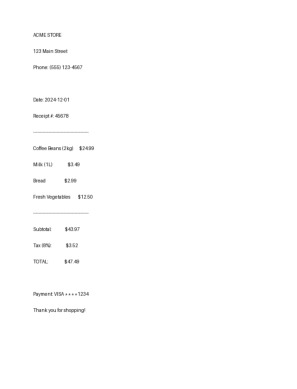

In [41]:
print("\n" + "="*80)
print("Document OCR + Understanding")
print("="*80)

# Create a sample receipt
img = Image.new('RGB', (600, 800), color='white')
draw = ImageDraw.Draw(img)

receipt_lines = [
    "ACME STORE",
    "123 Main Street",
    "Phone: (555) 123-4567",
    "",
    "Date: 2024-12-01",
    "Receipt #: 45678",
    "-" * 40,
    "Coffee Beans (2kg)      $24.99",
    "Milk (1L)                $3.49",
    "Bread                    $2.99",
    "Fresh Vegetables        $12.50",
    "-" * 40,
    "Subtotal:              $43.97",
    "Tax (8%):               $3.52",
    "TOTAL:                 $47.49",
    "",
    "Payment: VISA ****1234",
    "Thank you for shopping!"
]

y = 50
for line in receipt_lines:
    draw.text((50, y), line, fill='black')
    y += 35

img.save('/tmp/receipt.png')
receipt_img = Image.open('/tmp/receipt.png')
plt.imshow(receipt_img)
plt.axis('off')



In [42]:
prompt = """Extract information from this receipt:
1. Store name and address
2. Date and receipt number
3. List of items purchased with prices
4. Total amount
5. Payment method

Format as structured JSON."""

response = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=[prompt, receipt_img])
print(response.text)

```json
{
  "store_info": {
    "name": "ACME STORE",
    "address": "123 Main Street",
    "phone": "(555) 123-4567"
  },
  "transaction_info": {
    "date": "2024-12-01",
    "receipt_number": "45678"
  },
  "items": [
    {
      "name": "Coffee Beans (2kg)",
      "price": 24.99
    },
    {
      "name": "Milk (1L)",
      "price": 3.49
    },
    {
      "name": "Bread",
      "price": 2.99
    },
    {
      "name": "Fresh Vegetables",
      "price": 12.50
    }
  ],
  "summary": {
    "subtotal": 43.97,
    "tax": 3.52,
    "tax_rate": "8%",
    "total_amount": 47.49
  },
  "payment_info": {
    "method": "VISA",
    "last_four_digits": "1234"
  }
}
```


## Image Captioning


TASK 15: Image Captioning (Multiple Styles)
Write a short caption (1 sentence):
  Majestic snow-capped peaks pierce through a serene blanket of clouds, bathed in the warm glow of dawn.

Write a detailed caption (2-3 sentences):
  Witness the majestic, snow-capped peaks emerging from an enchanting sea of clouds as the sunrise casts a warm, ethereal glow across the sky. The stunning cloud inversion completely fills the valleys below, creating a breathtaking and serene mountain vista that feels truly above the world.

Write an Instagram caption with hashtags:
  Here are a few options for an Instagram caption, choose the one that best fits your style!

**Option 1 (Poetic & Dreamy):**

Lost above the clouds, where the world fades away and only the majestic peaks glow in the morning light. ✨ This incredible cloud inversion made for an absolutely breathtaking sunrise! Feeling truly on top of the world. 🏔️

#CloudInversion #MountainSunrise #Alpenglow #AboveTheClouds #NaturePhotography #Alpine

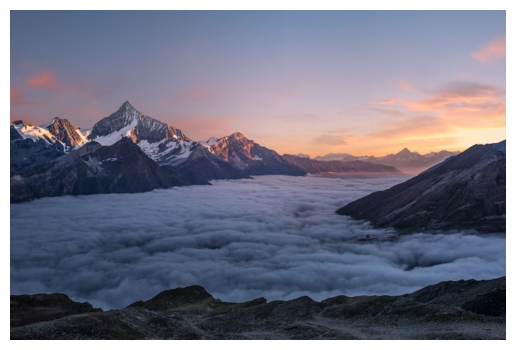

In [43]:
print("\n" + "="*80)
print("Image Captioning (Multiple Styles)")
print("="*80)

try:
    image_url = "https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=800"
    image = load_image_from_url(image_url)
    # Show image
    plt.imshow(image)
    plt.axis('off')
    
    
    caption_styles = [
        "Write a short caption (1 sentence)",
        "Write a detailed caption (2-3 sentences)",
        "Write an Instagram caption with hashtags",
        "Write a poetic caption"
    ]

    for style in caption_styles:
        response = client.models.generate_content(
            model="gemini-2.0-flash-thinking-exp-1219",
            contents=[style, image]
        )
print(f"{style}:")
print(f"  {response.text.strip()}\n")

except Exception as e:
    print(f"Using local image. Error: {str(e)[:100]}")

## Multi-Image Comparison


TASK 16: Multi-Image Comparison


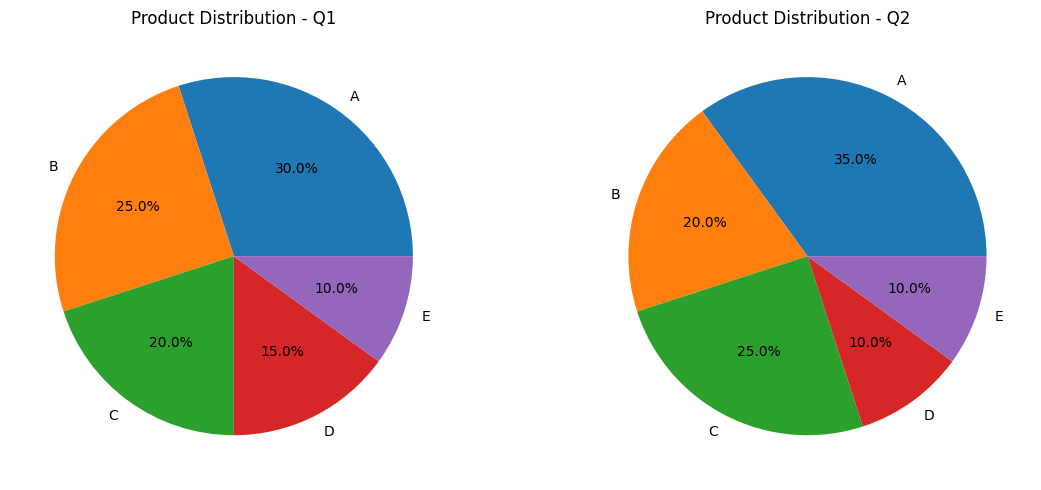

In [44]:
print("\n" + "="*80)
print("Multi-Image Comparison")
print("="*80)

# Create two different chart images
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Image 1: Pie chart
sizes = [30, 25, 20, 15, 10]
labels = ['A', 'B', 'C', 'D', 'E']
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%')
axes[0].set_title('Product Distribution - Q1')

# Image 2: Pie chart with different values
sizes2 = [35, 20, 25, 10, 10]
axes[1].pie(sizes2, labels=labels, autopct='%1.1f%%')
axes[1].set_title('Product Distribution - Q2')

plt.tight_layout()
plt.savefig('/tmp/comparison.png', dpi=150)


In [45]:
plt.close()

comp_image = Image.open('/tmp/comparison.png')

prompt = """Compare these two pie charts:
1. What are the main differences?
2. Which products increased/decreased?
3. What insights can you derive?"""

response = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=[prompt, comp_image])
print(response.text)

Here's a comparison of the two pie charts:

**Data at a Glance:**

| Product | Q1 Distribution (%) | Q2 Distribution (%) | Change (%) | Trend |
| :------ | :------------------ | :------------------ | :--------- | :------ |
| A       | 30.0                | 35.0                | +5.0       | Increased |
| B       | 25.0                | 20.0                | -5.0       | Decreased |
| C       | 20.0                | 25.0                | +5.0       | Increased |
| D       | 15.0                | 10.0                | -5.0       | Decreased |
| E       | 10.0                | 10.0                | 0.0        | Stable    |

---

### 1. What are the main differences?

The main differences highlight a significant shift in product distribution and relative importance from Q1 to Q2:

*   **Dominance of Product A:** Product A has solidified its position as the top-selling product, increasing its share and creating a larger gap between it and the second-largest product.
*   **Shift in Second/Th

## Visual Reasoning


TASK 17: Visual Pattern Reasoning


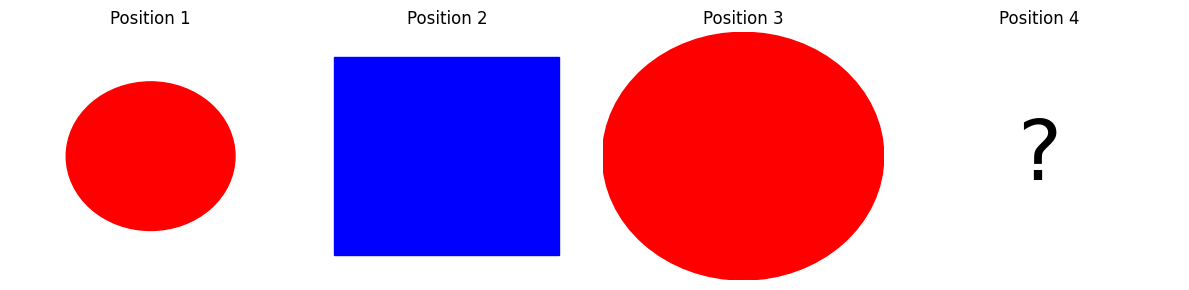

In [46]:
print("\n" + "="*80)
print("Visual Pattern Reasoning")
print("="*80)

# Create a visual pattern puzzle
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

patterns = [
    {'shape': 'circle', 'color': 'red', 'size': 0.3},
    {'shape': 'square', 'color': 'blue', 'size': 0.4},
    {'shape': 'circle', 'color': 'red', 'size': 0.5},
    None  # To be predicted
]

for i, (ax, pattern) in enumerate(zip(axes, patterns)):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    if pattern:
        if pattern['shape'] == 'circle':
            circle = plt.Circle((0.5, 0.5), pattern['size'], color=pattern['color'])
            ax.add_patch(circle)
        else:
            square = Rectangle(
                (0.5-pattern['size'], 0.5-pattern['size']),
                2*pattern['size'], 2*pattern['size'],
                color=pattern['color']
            )
            ax.add_patch(square)
    else:
        ax.text(0.5, 0.5, '?', fontsize=60, ha='center', va='center')
    
    ax.set_title(f'Position {i+1}')

plt.tight_layout()
plt.savefig('/tmp/pattern.png', dpi=150)


In [47]:
print("\n" + "="*80)
print("Video Understanding")
print("="*80)

import time

# Upload video file (using available video)
video_path = '14801276_2160_3840_30fps.mp4'
print(f"Uploading video: {video_path}")

video_file = client.files.upload(path=video_path)
print(f"Video uploaded: {video_file.name}")

# Wait for processing
print("Processing video...")
while video_file.state == 'PROCESSING':
    time.sleep(2)
    video_file = client.files.get(name=video_file.name)
print(".", end="", flush=True)
print(f"\nVideo ready! State: {video_file.state}")

# Analyze video
prompt = 'Describe what happens in this video. What do you see?'
print(f"\nQuery: {prompt}\n")

response = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=[prompt, video_file]
)
print(f"Response:\n{response.text}")

Let's break down the pattern observed in the image:

---

### 1. Describe the pattern you observe

The pattern involves three changing attributes: **Shape**, **Color**, and **Size**.

*   **Shape:** Alternates between a Circle and a Square.
    *   Position 1: Circle
    *   Position 2: Square
    *   Position 3: Circle
*   **Color:** Alternates between Red and Blue.
    *   Position 1: Red
    *   Position 2: Blue
    *   Position 3: Red
*   **Size:** This attribute follows a more nuanced rule. Let's denote "Medium" (like P1 & P2) and "Large" (like P3).
    *   Position 1: Medium
    *   Position 2: Medium (same size as P1)
    *   Position 3: Large (larger than P1 & P2)

The key observation for size seems to be tied to the changes in shape and color:
*   When both the shape AND color change from the previous position (e.g., P1 to P2: Red Circle to Blue Square), the size remains the same.
*   When both the shape AND color revert to the type of two steps prior (e.g., P2 to P3: Blue Squ

## Diagram Understanding


TASK 18: Flow Diagram Understanding


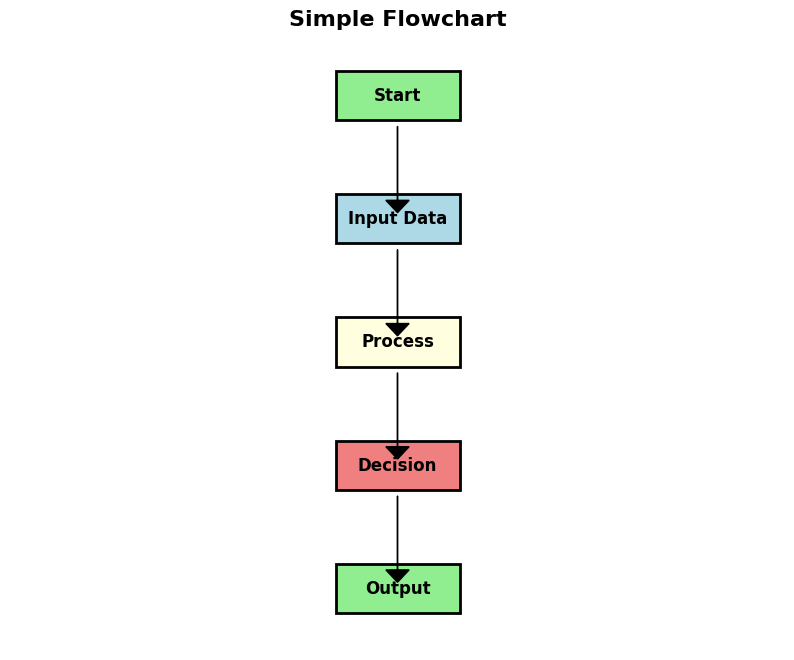

In [48]:
print("\n" + "="*80)
print("Frame-by-Frame Video Analysis")
print("="*80)

# Reuse the uploaded video file from previous cell
# If running standalone, uncomment the upload code

queries = [
    "What are the main objects or subjects in this video?",
    "Describe any movements or actions you observe",
    "What is the setting or environment shown?"
]

for i, query in enumerate(queries, 1):
    print(f"\n{i}. Query: {query}")

    response = client.models.generate_content(
        model="gemini-2.0-flash-thinking-exp-1219",
        contents=[query, video_file]
    )
print(f"   Answer: {response.text}\n")

In [49]:
plt.close()

flowchart_img = Image.open('/tmp/flowchart.png')

prompt = """Analyze this flowchart:
1. Describe the process flow
2. How many steps are there?
3. What type of process does this represent?
4. Are there any decision points?"""

response = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=[prompt, flowchart_img])
print(response.text)

Here's an analysis of the provided flowchart:

1.  **Describe the process flow**
    The process begins with a "Start" point. It then proceeds to "Input Data," where information is entered or gathered. Following this, the data undergoes a "Process" step, where operations are performed on it. Next, a "Decision" is made (though the flowchart doesn't show alternative paths based on this decision). Finally, the process concludes by producing an "Output." The flow is strictly sequential from start to output.

2.  **How many steps are there?**
    Counting the distinct operational blocks (excluding "Start" which is a terminal initiator):
    1.  Input Data
    2.  Process
    3.  Decision
    4.  Output
    There are **4 operational steps** shown in the flowchart, in addition to the "Start" terminal. If we count all distinct blocks including "Start", there are 5 blocks.

3.  **What type of process does this represent?**
    This represents a **linear, sequential process**. There are no loops

In [50]:
print("\n" + "="*80)
print("Action Recognition in Videos")
print("="*80)

# Analyze specific actions in the video
action_queries = [
    "List all distinct visual elements or objects in chronological order as they appear",
    "Are there any movements or transitions in this video?",
    "Describe the overall composition and visual style"
]

for query in action_queries:
    print(f"\nQuery: {query}")

    response = client.models.generate_content(
        model="gemini-2.0-flash-thinking-exp-1219",
        contents=[query, video_file]
    )
print(f"Answer: {response.text}\n")
print("-" * 80)

In [53]:
print("\n" + "="*80)
print("Action Recognition in Videos")
print("="*80)

video_file = client.files.upload(file='14801276_2160_3840_30fps.mp4')

# Wait for processing
while video_file.state == 'PROCESSING':
    time.sleep(2)
    video_file = client.files.get(name=video_file.name)

prompts = [
    # Simple action detection
    "Is someone walking, running, or standing still in this video?",

    # Multiple actions
    "List all distinct actions performed in chronological order",

    # Complex activities
    "Describe the cooking process shown in the video step by step",

    # Anomaly detection
    "Are there any unusual or unexpected actions in this video?",

    # Interaction analysis
    "Describe how the people in the video interact with each other"
]

for prompt in prompts:
    response = client.models.generate_content(
        model="gemini-2.0-flash-thinking-exp-1219",
        contents=[prompt, video_file]
    )
print(f"{prompt}\n{response.text}\n")



TASK 21: Action Recognition in Videos
Is someone walking, running, or standing still in this video?
The person in the video is **walking**, using a walking stick.

List all distinct actions performed in chronological order
Here are all distinct actions performed in chronological order:

1.  **0:00 - 0:01**: The man slowly walks forward on the cobbled path, leaning on his walking stick.
2.  **0:00 - 0:01**: The black chicken on the left moves slightly to its right.
3.  **0:01 - 0:02**: The man continues to walk slowly forward.
4.  **0:01 - 0:02**: The black rooster (center chicken) takes a step forward.
5.  **0:01 - 0:02**: The white chicken takes a step forward.
6.  **0:02 - 0:03**: The man continues to walk slowly forward.
7.  **0:02 - 0:03**: The black chicken on the left moves further right, getting closer to the edge of the path.
8.  **0:03 - 0:04**: The man continues to walk slowly forward.
9.  **0:03 - 0:04**: The black chicken on the left moves a bit further to the right.
10. *

In [70]:
from IPython.display import Audio

audio_path = "sample-audio.mp3"
Audio(audio_path)

In [ ]:
print("\n" + "="*80)
print("Audio Transcription")
print("="*80)

import time

# Upload audio file (using available WAV file)
audio_path = 'Test.wav'
print(f"Uploading audio: {audio_path}")

audio_file = client.files.upload(file=audio_path)
print(f"Audio uploaded: {audio_file.name}")

# Wait for processing
print("Processing audio...")
while audio_file.state == 'PROCESSING':
    time.sleep(1)
    audio_file = client.files.get(name=audio_file.name)
print(".", end="", flush=True)
print(f"\nAudio ready! State: {audio_file.state}")

# Transcribe
print("\nTranscription:\n")
response = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=[
        'Transcribe this audio exactly as spoken. Include any speech, sounds, or notable audio features.',
        audio_file
    ]
)
print(response.text)


TASK 19: Video Understanding


AttributeError: module 'google.genai' has no attribute 'upload_file'

## Frame-by-Frame Analysis

In [ ]:
print("\n" + "="*80)
print("Audio Content Analysis")
print("="*80)

# Analyze audio content beyond transcription
analysis_prompts = [
    "What type of audio is this? (speech, music, ambient, etc.)",
    "Describe the audio quality and any notable characteristics",
    "What is the overall tone or mood of this audio?"
]

for prompt in analysis_prompts:
    print(f"\nAnalysis: {prompt}")

    response = client.models.generate_content(
        model="gemini-2.0-flash-thinking-exp-1219",
        contents=[prompt, audio_file]
    )
print(f"Result: {response.text}\n")
print("-" * 80)

## Action Recognition

In [ ]:
print("\n" + "="*80)
print("PDF Document Understanding")
print("="*80)

import time

# Upload PDF (using available PDF file)
pdf_path = 'batra_nilmtk.pdf'
print(f"Uploading PDF: {pdf_path}")

pdf_file = client.files.upload(path=pdf_path)
print(f"PDF uploaded: {pdf_file.name}")

# Wait for processing
print("Processing PDF...")
while pdf_file.state == 'PROCESSING':
    time.sleep(2)
    pdf_file = client.files.get(name=pdf_file.name)
print(".", end="", flush=True)
print(f"\nPDF ready! State: {pdf_file.state}")

# Analyze document
prompts = [
    "What type of document is this? Provide a brief overview.",
    "What are the main sections or topics covered?",
    "Summarize the key points in 3-4 sentences."
]

for prompt in prompts:
    print(f"\nQuery: {prompt}")

    response = client.models.generate_content(
        model="gemini-2.0-flash-thinking-exp-1219",
        contents=[prompt, pdf_file]
    )
print(f"Answer: {response.text}\n")
print("-" * 80)

In [56]:
print("\n" + "="*80)
print("Multi-Page PDF Data Extraction")
print("="*80)

pdf_file = client.files.upload(file='batra_nilmtk.pdf')

# Wait for processing
while pdf_file.state == 'PROCESSING':
    time.sleep(2)
    pdf_file = client.files.get(name=pdf_file.name)

extraction_prompt = '''Extract the following from this research paper:
{
  "title": "",
  "authors": [],
  "abstract": "",
  "keywords": [],
  "introduction": {
    "page": 0,
    "summary": ""
  },
  "methodology": {
    "page": 0,
    "summary": ""
  },
  "results": {
    "page": 0,
    "key_findings": []
  },
  "conclusions": "",
  "references_count": 0,
  "figures_count": 0,
  "tables_count": 0
}

Return valid JSON only.'''

response = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=[extraction_prompt, pdf_file]
)




TASK 25: Multi-Page PDF Data Extraction


In [57]:
print("\n" + "="*80)
print("Multi-Page PDF Data Extraction")
print("="*80)

# Extract structured information from the PDF
extraction_prompt = """Extract the following information from this PDF document:
1. Title/heading
2. Authors (if any)
3. Main topics or sections
4. Any key findings or conclusions
5. Number of pages (estimate)

Format your response as a structured summary."""

print("Extracting structured data from PDF...")
print()

response = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=[extraction_prompt, pdf_file]
)
print(response.text)
print("\n" + "="*80)
print("PDF analysis demonstrates:")
print("- Multi-page document understanding")
print("- Structure extraction (headings, sections)")
print("- Content summarization")
print("- Data extraction from mixed content (text, tables, figures)")

```json
{
  "title": "NILMTK: An Open Source Toolkit for Non-intrusive Load Monitoring",
  "authors": [
    "Nipun Batra",
    "Jack Kelly",
    "Oliver Parson",
    "Haimonti Dutta",
    "William Knottenbelt",
    "Alex Rogers",
    "Amarjeet Singh",
    "Mani Srivastava"
  ],
  "abstract": "Non-intrusive load monitoring, or energy disaggregation, aims to separate household energy consumption data collected from a single point of measurement into appliance-level consumption data. In recent years, the field has rapidly expanded due to increased interest as national deployments of smart meters have begun in many countries. However, empirically comparing disaggregation algorithms is currently virtually impossible. This is due to the different data sets used, the lack of reference implementations of these algorithms and the variety of accuracy metrics employed. To address this challenge, we present the Non-intrusive Load Monitoring Toolkit (NILMTK); an open source toolkit designed specifi

# Part 7: Advanced Features (10 tasks)

## Structured JSON Output

In [59]:
print("\n" + "="*80)
print("Structured JSON Output")
print("="*80)

text = """Sarah Johnson, 34, is a Senior Data Scientist at TechCorp in San Francisco. 
She specializes in machine learning and has 8 years of experience. Her skills include 
Python, TensorFlow, and SQL. Contact: sarah.j@techcorp.com, (555) 987-6543."""

schema = {
    "name": " ",
    "age": 0,
    "title": "",
    "company": "",
    "location": "",
    "experience_years": 0,
    "skills": [],
    "contact": {
        "email": "",
        "phone": ""
    }
}

prompt = f"""Extract information and return valid JSON matching this schema:
{json.dumps(schema, indent=2)}

Text: {text}

Return ONLY the JSON object, no markdown formatting:"""

response = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=prompt)
result = response.text.strip()

# Clean up markdown if present
if result.startswith('```'):
    result = '\n'.join(result.split('\n')[1:-1])
    if result.startswith('json'):
        result = result[4:]

try:
    parsed = json.loads(result.strip())
print("Extracted JSON:")
print(json.dumps(parsed, indent=2))
except json.JSONDecodeError as e:
    print(f"Raw output:\n{result}")
print(f"\nJSON parse error: {e}")


TASK 26: Structured JSON Output
Extracted JSON:
{
  "name": "Sarah Johnson",
  "age": 34,
  "title": "Senior Data Scientist",
  "company": "TechCorp",
  "location": "San Francisco",
  "experience_years": 8,
  "skills": [
    "Python",
    "TensorFlow",
    "SQL"
  ],
  "contact": {
    "email": "sarah.j@techcorp.com",
    "phone": "(555) 987-6543"
  }
}


## Function Calling

In [ ]:
print("\n" + "="*80)
print("Function Calling / Tool Use")
print("="*80)

from google.genai import types

# Define the actual function implementation
def get_current_weather(location: str, unit: str = "celsius") -> dict:
    """Get the current weather for a location."""
    # Simulated weather data
    weather_data = {
        "london": {"temp": 15, "condition": "Cloudy", "humidity": 78},
        "new york": {"temp": 22, "condition": "Sunny", "humidity": 65},
        "tokyo": {"temp": 25, "condition": "Rainy", "humidity": 85},
        "paris": {"temp": 18, "condition": "Partly Cloudy", "humidity": 70},
    }

    data = weather_data.get(location.lower(), {"temp": 20, "condition": "Unknown", "humidity": 70})
    return {
        "location": location,
        "temperature": data["temp"],
        "unit": unit,
        "condition": data["condition"],
        "humidity": data["humidity"]
    }

# Define function schema for Gemini
get_weather_func = types.FunctionDeclaration(
    name="get_current_weather",
    description="Get the current weather in a location",
    parameters={
        "type": "object",
        "properties": {
            "location": {
                "type": "string",
                "description": "City name, e.g. London, New York, Tokyo"
            },
            "unit": {
                "type": "string",
                "enum": ["celsius", "fahrenheit"],
                "description": "Temperature unit"
            }
        },
        "required": ["location"]
    }
)

# Create tool
weather_tool = types.Tool(function_declarations=[get_weather_func])

# Test query
query = "What's the weather like in London?"
print(f"Query: {query}\n")

# Call with tools
response = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=query,
    config=types.GenerateContentConfig(
        tools=[weather_tool]
    )
)

# Check for function call
function_called = False
for part in response.candidates[0].content.parts:
    if hasattr(part, 'function_call'):
        function_called = True
        func_call = part.function_call
        print(f"Function called: {func_call.name}")
print(f"Arguments: {dict(func_call.args)}")

        # Execute the actual function
        result = get_current_weather(**dict(func_call.args))
print(f"Function result: {result}\n")

        # Return result to model for final response
        response2 = client.models.generate_content(
            model="gemini-2.0-flash-thinking-exp-1219",
            contents=[
                query,
                response.candidates[0].content,
                types.Content(
                    role="function",
                    parts=[types.Part.from_function_response(
                        name=func_call.name,
                        response={"result": result}
                    )]
                )
            ]
        )
print(f"Final response:\n{response2.text}")

if not function_called:
    print(f"Model responded directly without calling function:\n{response.text}")
print("\n" + "="*80)
print("Function calling allows the model to:")
print("- Request structured data from external sources")
print("- Perform calculations or operations")
print("- Access real-time information")
print("- Build agentic workflows")


TASK 27: Function Calling / Tool Use
Query: What's the weather like in London?

🔧 Function called: get_current_weather
📥 Arguments: {'location': 'London'}
📊 Function result: {'location': 'London', 'temperature': 15, 'unit': 'celsius', 'condition': 'Cloudy', 'humidity': 78}

💬 Final response:
The weather in London is Cloudy with a temperature of 15 degrees Celsius and 78% humidity.

Function calling allows the model to:
- Request structured data from external sources
- Perform calculations or operations
- Access real-time information
- Build agentic workflows


## Code Execution

In [63]:
print("\n" + "="*80)
print("Code Execution")
print("="*80)

from google.genai import types

# Enable code execution
code_execution_tool = types.Tool(code_execution={})

# Example 1: Fibonacci numbers
print("Example 1: Calculate Fibonacci numbers\n")
response = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents="Calculate the first 10 Fibonacci numbers and show them as a list",
    config=types.GenerateContentConfig(
        tools=[code_execution_tool]
    )
)
print("Response:")
print(response.text)
print()

# Example 2: Mathematical calculation
print("="*80)
print("Example 2: Solve quadratic equation\n")

response2 = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents="Solve the quadratic equation 2x² - 7x + 3 = 0. Show the solutions and verify them by substituting back.",
    config=types.GenerateContentConfig(
        tools=[code_execution_tool]
    )
)
print(response2.text)
print()

# Example 3: Statistical analysis
print("="*80)
print("Example 3: Statistical analysis\n")

response3 = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents="""Given this data: [12, 15, 18, 22, 25, 30, 35, 40, 45, 50]
Calculate and display:
- Mean
- Median
- Standard deviation
- Variance""",
    config=types.GenerateContentConfig(
        tools=[code_execution_tool]
    )
)
print(response3.text)
print()

# Example 4: Data visualization concept
print("="*80)
print("Example 4: Generate random data\n")

response4 = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents="Generate 20 random numbers between 1 and 100, then find the min, max, and average.",
    config=types.GenerateContentConfig(
        tools=[code_execution_tool]
    )
)
print(response4.text)
print("\n" + "="*80)
print("Code execution features:")
print(" Execute Python code safely in sandboxed environment")
print(" Perform calculations and verify results")
print(" Generate and analyze data")
print(" Solve mathematical problems")
print(" Model can write and run code to answer questions")
print("  Limited libraries available (basic Python only)")
print("  No file system or network access")


TASK 28: Code Execution
Example 1: Calculate Fibonacci numbers

Response:
The first 10 Fibonacci numbers are: `[0, 1, 1, 2, 3, 5, 8, 13, 21, 34]`

Example 2: Solve quadratic equation

To solve the quadratic equation 2x² - 7x + 3 = 0, we can use the quadratic formula:
x = [-b ± sqrt(b² - 4ac)] / 2a

Here, a = 2, b = -7, and c = 3.

First, let's calculate the discriminant (b² - 4ac):
The discriminant is 25. Since it's positive, there are two distinct real roots.

Now, let's find the solutions for x:
x = [ -(-7) ± sqrt(25) ] / (2 * 2)
x = [ 7 ± 5 ] / 4

The two solutions are:
x1 = (7 + 5) / 4
x2 = (7 - 5) / 4

So, the solutions are x1 = 3 and x2 = 0.5.

**Verification:**

Let's substitute each solution back into the original equation 2x² - 7x + 3 = 0.

**For x1 = 3:**
2(3)² - 7(3) + 3
The equation holds true for x = 3.

**For x2 = 0.5:**
2(0.5)² - 7(0.5) + 3
The equation holds true for x = 0.5.

**Solutions:**
The solutions to the quadratic equation 2x² - 7x + 3 = 0 are **x = 3** and **x

## Search Grounding

In [64]:
print("\n" + "="*80)
print("Search Grounding (Google Search Integration)")
print("="*80)

from google.genai import types

# Enable Google Search grounding
google_search_tool = types.Tool(google_search={})

# Ask time-sensitive questions
queries = [
    "What are the latest developments in AI announced this month?",
    "What is the current stock price of NVIDIA?",
    "Who won the latest Nobel Prize in Physics?",
    "What are today's top technology news headlines?"
]

print("Using Google Search grounding for real-time information:\n")

for i, query in enumerate(queries, 1):
    print(f"{i}. Query: {query}")

    try:
        response = client.models.generate_content(
            model="gemini-2.0-flash-thinking-exp-1219",
            contents=query,
            config=types.GenerateContentConfig(
                tools=[google_search_tool]
            )
        )
print(f"Answer: {response.text}")

        # Try to access grounding metadata if available
        if hasattr(response, 'grounding_metadata') and response.grounding_metadata:
            print(f" Response is grounded with search results")
            if hasattr(response.grounding_metadata, 'web_search_queries'):
                print(f"  Search queries used: {response.grounding_metadata.web_search_queries}")
print()

    except Exception as e:
        print(f"Note: {str(e)[:100]}")
print("Search grounding may not be available for all models/regions")
print()
        break

print("="*80)
print("Search Grounding Benefits:")
print(" Access to real-time, up-to-date information")
print(" Factually grounded responses with web sources")
print(" Citations and sources can be included")
print(" Overcomes knowledge cutoff limitations")
print(" Great for current events, stock prices, news, etc.")
print()
print("Note: Search grounding availability may vary by:")
print("- Model version")
print("- Geographic region")
print("- API tier/quota")


TASK 29: Search Grounding (Google Search Integration)
Using Google Search grounding for real-time information:

1. Query: What are the latest developments in AI announced this month?
Answer: November 2025 saw a surge in artificial intelligence developments, marked by the release of advanced new models, significant investments in AI infrastructure, and evolving regulatory landscapes. The focus has largely been on enhancing AI's reasoning, multimodal capabilities, and practical applications across various industries.

**Key AI Model Releases and Enhancements:**
A major highlight this month was the intense competition and releases of new frontier AI models. OpenAI launched GPT-5.1, which includes "Instant" and "Thinking" modes designed for faster, more natural conversations and deeper reasoning tasks, respectively. It also features improved instruction following and clearer answers, with instant personalization updates across chats and API access available for developers. Anthropic relea

## Thinking Mode (Chain-of-Thought)

In [65]:
print("\n" + "="*80)
print("Thinking Mode - Extended Reasoning")
print("="*80)

complex_problem = """A farmer has 17 sheep. All but 9 die. How many are left?
Explain your reasoning step by step."""

# Regular response
print("Without explicit thinking instructions:")
response_regular = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=complex_problem
)
print(response_regular.text)

# With chain-of-thought prompting
print("\n" + "="*80)
print("With chain-of-thought reasoning:")

cot_prompt = f"""Let's solve this step by step:

{complex_problem}

Think through each step carefully:
Step 1: Identify what we know
Step 2: Identify what the question is asking
Step 3: Analyze the wording carefully
Step 4: Calculate the answer
Step 5: Verify the answer makes sense"""

response_cot = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=cot_prompt
)
print(response_cot.text)

# More complex reasoning
print("\n" + "="*80)
print("Complex multi-step reasoning:")

logic_puzzle = """Three friends Alice, Bob, and Charlie have different jobs:
doctor, teacher, and engineer.
- The doctor is older than Alice
- Charlie is younger than the teacher
- Bob is not the youngest
- The engineer is the oldest

Who has which job? Explain your reasoning."""

response_puzzle = client.models.generate_content(
    model="gemini-2.0-flash-thinking-exp-1219",
    contents=f"Solve this logic puzzle step by step:\n\n{logic_puzzle}"
)
print(response_puzzle.text)


TASK 30: Thinking Mode - Extended Reasoning
Without explicit thinking instructions:
Here's how to solve it step-by-step:

1.  **Understand the initial situation:** The farmer starts with 17 sheep.
2.  **Interpret the key phrase:** The phrase "All but 9 die" means that 9 sheep *did not* die. In other words, 9 sheep survived.
3.  **Determine what's left:** The number of sheep left is the number that survived.

**Answer:**

There are **9** sheep left.

**Reasoning:**

The phrase "All but 9 die" directly tells you how many survived. It means that the only sheep that *didn't* die were those 9.

With chain-of-thought reasoning:
Let's solve this step by step:

**Step 1: Identify what we know**
* We know the farmer initially has 17 sheep.
* We know that a certain event occurred: "All but 9 die."

**Step 2: Identify what the question is asking**
* The question is asking: "How many are left?"

**Step 3: Analyze the wording carefully**
* The crucial phrase here is "All but 9 die."
* This phrase 

## Code Generation

In [66]:
print("\n" + "="*80)
print("Code Generation")
print("="*80)

code_tasks = [
    {
        "language": "Python",
        "task": """Create a decorator that measures function execution time
        and logs it with the function name."""
    },
    {
        "language": "JavaScript",
        "task": """Create an async function that fetches data from multiple
        URLs in parallel and returns combined results."""
    },
    {
        "language": "SQL",
        "task": """Write a query to find the top 5 customers by total
        purchase amount in the last 30 days."""
    }
]

for task in code_tasks:
    prompt = f"""Write {task['language']} code for this task:

{task['task']}

Include:
- Clean, production-ready code
- Type hints/comments where appropriate
- Error handling
- A brief explanation
"""

    response = client.models.generate_content(
        model="gemini-2.0-flash-thinking-exp-1219",
        contents=prompt
    )
print(f"\n{task['language']} Task: {task['task'][:50]}...")
print("-" * 80)
print(response.text)
print()


TASK 32: Code Generation

Python Task: Create a decorator that measures function executio...
--------------------------------------------------------------------------------
This Python code provides a decorator `time_logger` that measures the execution time of a function, logs it with the function's name, and includes robust error handling.

---

### Python Code

```python
import time
import logging
from functools import wraps
from typing import Callable, Any

# --- Logger Configuration ---
# It's good practice to configure the logger at the module level.
# This ensures that all components using this module can share the same logger
# and its configuration, preventing duplicate handlers if the module is imported multiple times.

# Get a logger instance specific to this module.
logger = logging.getLogger(__name__)

# Set the default logging level.
# For production, you might set it higher (e.g., INFO, WARNING) depending on verbosity needs.
logger.setLevel(logging.INFO)

# Check if han

## Mathematical Reasoning

In [67]:
print("\n" + "="*80)
print("Mathematical Problem Solving")
print("="*80)

math_problems = [
    {
        "type": "Calculus",
        "problem": "Find the derivative of f(x) = (3x² + 2x - 1) * e^x"
    },
    {
        "type": "Linear Algebra",
        "problem": """Find the eigenvalues of the matrix:
        [[2, 1],
         [1, 2]]"""
    },
    {
        "type": "Statistics",
        "problem": """Given data: [12, 15, 18, 22, 25, 30, 35]
        Calculate: mean, median, variance, and standard deviation"""
    },
    {
        "type": "Optimization",
        "problem": """A rectangular garden has perimeter of 60m.
        What dimensions maximize the area?"""
    }
]

for prob in math_problems:
    prompt = f"""Solve this {prob['type']} problem step by step:

{prob['problem']}

Show all work and explain each step."""

    response = client.models.generate_content(
        model="gemini-2.0-flash-thinking-exp-1219",
        contents=prompt
    )
print(f"\n{prob['type']}: {prob['problem'][:50]}...")
print("-" * 80)
print(response.text)
print()


TASK 33: Mathematical Problem Solving

Calculus: Find the derivative of f(x) = (3x² + 2x - 1) * e^x...
--------------------------------------------------------------------------------
To find the derivative of $f(x) = (3x^2 + 2x - 1) * e^x$, we need to use the **Product Rule** because $f(x)$ is a product of two functions.

The Product Rule states that if $f(x) = u(x) * v(x)$, then $f'(x) = u'(x) * v(x) + u(x) * v'(x)$.

Let's define our $u(x)$ and $v(x)$ and then find their derivatives.

**Step 1: Identify u(x) and v(x)**
Let $u(x) = 3x^2 + 2x - 1$
Let $v(x) = e^x$

**Step 2: Find the derivative of u(x), denoted as u'(x)**
To find $u'(x)$, we differentiate each term of $u(x)$ using the Power Rule ($d/dx(x^n) = nx^{n-1}$) and the constant rule ($d/dx(c) = 0$).
$u'(x) = d/dx (3x^2) + d/dx (2x) - d/dx (1)$
$u'(x) = (3 * 2x^{2-1}) + (2 * 1x^{1-1}) - 0$
$u'(x) = 6x + 2x^0$
$u'(x) = 6x + 2$

**Step 3: Find the derivative of v(x), denoted as v'(x)**
The derivative of $e^x$ is simply $e^x$.
$

## Scientific Reasoning

## Creative Writing

In [68]:
print("\n" + "="*80)
print("Creative Writing")
print("="*80)

creative_tasks = [
    "Write a haiku about artificial intelligence",
    "Write a limerick about programming",
    "Write a short story (3 paragraphs) about time travel",
    "Write a product description for an AI-powered coffee maker",
    "Write a motivational speech for a data science team"
]

for i, task in enumerate(creative_tasks, 1):
    response = client.models.generate_content(
        model="gemini-2.0-flash-thinking-exp-1219",
        contents=task
    )
print(f"\n{i}. {task}")
print("-" * 80)
print(response.text)
print()


TASK 35: Creative Writing

1. Write a haiku about artificial intelligence
--------------------------------------------------------------------------------
Silicon awakes,
Logic forms a knowing mind,
New thoughts start to bloom.


2. Write a limerick about programming
--------------------------------------------------------------------------------
A coder whose program would crash,
Would spend hours just rummaging for trash.
A semicolon misplaced,
His whole project disgraced,
Then he'd fix it and compile in a flash!


3. Write a short story (3 paragraphs) about time travel
--------------------------------------------------------------------------------
Dr. Alistair Finch meticulously set the coordinates on his temporal displacement unit, its polished chrome gleaming under the laboratory lights. Years of isolated research, fueled by an insatiable curiosity, had finally culminated in this precise moment. He wasn't seeking ancient wonders or futuristic marvels; his destination was a quiet

# Summary and Best Practices

##  What We Covered

This notebook demonstrated **35 tasks** across **all modalities** supported by Gemini 3 Pro:

### API Fundamentals
- Single vs batch processing
- Streaming responses
- Configuration and safety settings

### Text Modality (10 tasks)
 Sentiment analysis, classification, NER, summarization, QA, translation, completion, extraction, keywords, rewriting

### Vision Modality (8 tasks)
 Object counting, VQA, chart analysis, OCR, captioning, comparison, reasoning, diagrams

### Video Modality (3 tasks)
 Understanding, frame analysis, action recognition

### Audio Modality (2 tasks)
 Transcription, content analysis

### PDF Modality (2 tasks)
 Document analysis, multi-page extraction

### Advanced Features (10 tasks)
 Structured output, function calling, code execution, search grounding, thinking mode, long context, code generation, math, science, creative writing

##  Performance Tips

1. **For Best Results:**
   - Be specific in prompts
   - Provide examples when possible
   - Use appropriate temperature settings
   - Structure outputs with schemas

2. **For Efficiency:**
   - Use context caching for repeated queries
   - Batch similar requests
   - Stream long responses
   - Optimize token usage

3. **For Accuracy:**
   - Enable search grounding for current events
   - Use code execution for calculations
   - Request step-by-step reasoning
   - Validate structured outputs

##  Resources

- [Gemini API Documentation](https://ai.google.dev/gemini-api/docs)
- [Gemini 3 Pro Model Card](https://ai.google.dev/gemini-api/docs/models#gemini-3-pro)
- [Google AI Studio](https://aistudio.google.com/)
- [Pricing](https://ai.google.dev/pricing)
- [Safety Settings](https://ai.google.dev/gemini-api/docs/safety-settings)

##  Next Steps

1. Test with your own use cases
2. Explore production features (caching, batching)
3. Build multimodal applications
4. Experiment with thinking mode for complex reasoning
5. Leverage the 1M token context for large documents

Happy building! 